In [3]:
import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

DATASET_PATH = "/kaggle/input/datasets/aishikai/asl-alphabets/asl_alphabets"  # change this

TRAIN_DIR = os.path.join(DATASET_PATH, "train")
TEST_DIR = os.path.join(DATASET_PATH, "test")

TRAIN_CSV = os.path.join(DATASET_PATH, "Training_set.csv")

In [4]:
# Load CSV
train_df = pd.read_csv(TRAIN_CSV)

print(train_df.head())
print(train_df.columns)
print(f"Total Training Samples: {len(train_df)}")

      filename label
0  Image_1.jpg     B
1  Image_2.jpg     P
2  Image_3.jpg     J
3  Image_4.jpg     T
4  Image_5.jpg     B
Index(['filename', 'label'], dtype='object')
Total Training Samples: 60900


In [5]:
# Expected columns check
required_cols = ['filename', 'label']

for col in required_cols:
    if col not in train_df.columns:
        raise ValueError(f"Missing column: {col}")

print("CSV format is valid ✅")

CSV format is valid ✅


In [6]:
train_df['path'] = train_df['filename'].apply(
    lambda x: os.path.join(TRAIN_DIR, x)
)

print(train_df.head())

      filename label                                               path
0  Image_1.jpg     B  /kaggle/input/datasets/aishikai/asl-alphabets/...
1  Image_2.jpg     P  /kaggle/input/datasets/aishikai/asl-alphabets/...
2  Image_3.jpg     J  /kaggle/input/datasets/aishikai/asl-alphabets/...
3  Image_4.jpg     T  /kaggle/input/datasets/aishikai/asl-alphabets/...
4  Image_5.jpg     B  /kaggle/input/datasets/aishikai/asl-alphabets/...


In [7]:
# Check missing files
missing_files = train_df[~train_df['path'].apply(os.path.exists)]

print(f"Missing Images: {len(missing_files)}")

# Check duplicates
duplicates = train_df[train_df.duplicated(subset=['filename'])]
print(f"Duplicate filenames: {len(duplicates)}")

# Unique classes
classes = sorted(train_df['label'].unique())
print(f"Total Classes: {len(classes)}")
print(classes)

Missing Images: 0
Duplicate filenames: 0
Total Classes: 29
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


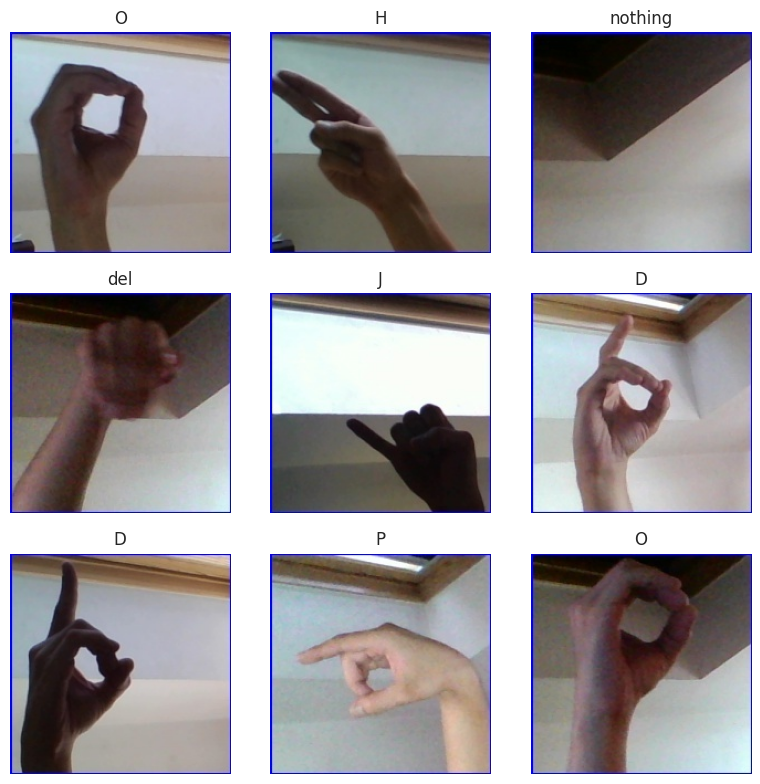

In [8]:
def show_samples(df, n=9):
    sample = df.sample(n)
    
    plt.figure(figsize=(8,8))
    
    for i, (_, row) in enumerate(sample.iterrows()):
        img = cv2.imread(row['path'])
        
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            plt.subplot(3,3,i+1)
            plt.imshow(img)
            plt.title(row['label'])
            plt.axis("off")
    
    plt.tight_layout()
    plt.show()

show_samples(train_df, n=9)

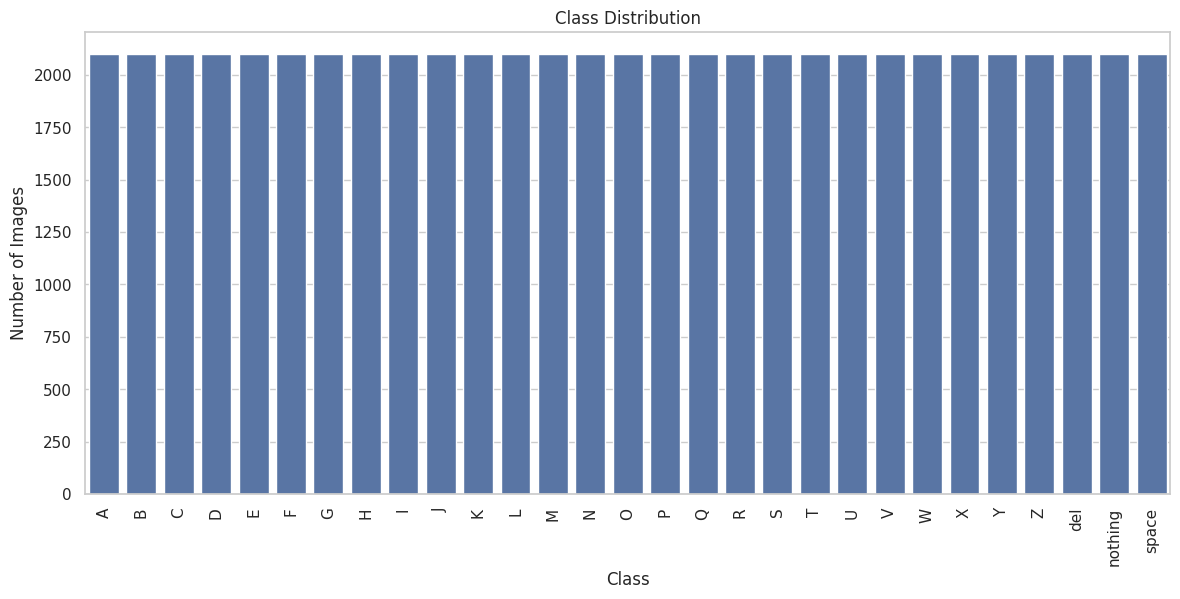

count      29.0
mean     2100.0
std         0.0
min      2100.0
25%      2100.0
50%      2100.0
75%      2100.0
max      2100.0
Name: count, dtype: float64


In [10]:
df = train_df
class_counts = df['label'].value_counts().sort_index()

plt.figure(figsize=(14,6))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.xticks(rotation=90)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

print(class_counts.describe())

In [11]:
imbalance_ratio = class_counts.max() / class_counts.min()
print(f"Imbalance Ratio: {imbalance_ratio:.2f}")

Imbalance Ratio: 1.00


In [12]:
heights = []
widths = []

for path in tqdm(df['path']):
    img = cv2.imread(path)
    if img is not None:
        h, w = img.shape[:2]
        heights.append(h)
        widths.append(w)

df['height'] = heights
df['width'] = widths

100%|██████████| 60900/60900 [04:42<00:00, 215.89it/s]


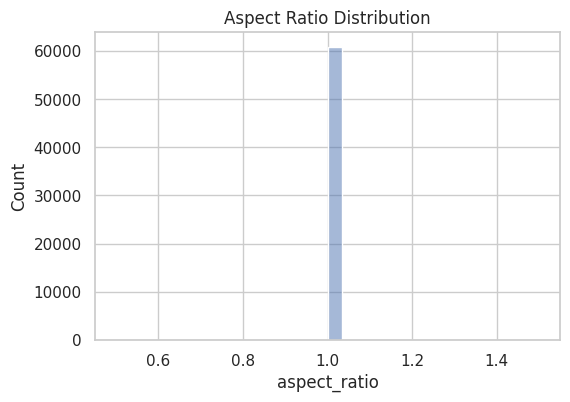

In [14]:
df['aspect_ratio'] = df['width'] / df['height']

plt.figure(figsize=(6,4))
sns.histplot(df['aspect_ratio'], bins=30, kde=True)
plt.title("Aspect Ratio Distribution")
plt.show()

100%|██████████| 500/500 [00:02<00:00, 227.08it/s]


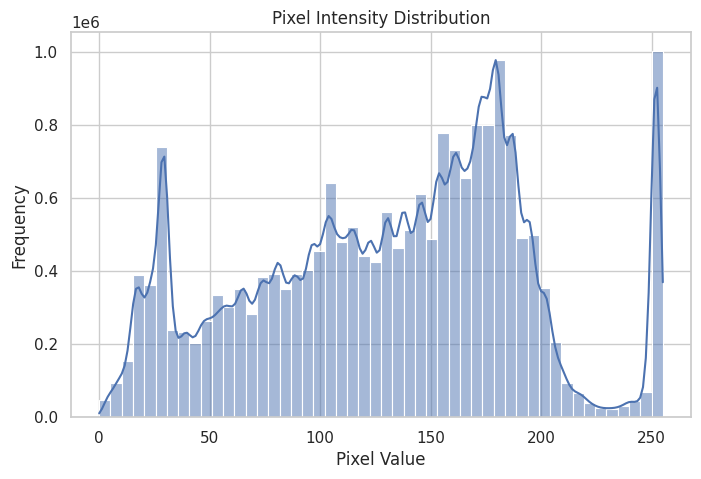

In [15]:
pixel_values = []

for path in tqdm(df['path'].sample(500)):  # sample for speed
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is not None:
        pixel_values.extend(img.flatten())

pixel_values = np.array(pixel_values)

plt.figure(figsize=(8,5))
sns.histplot(pixel_values, bins=50, kde=True)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

In [16]:
corrupt_images = []

for path in tqdm(df['path']):
    try:
        img = cv2.imread(path)
        if img is None:
            corrupt_images.append(path)
    except:
        corrupt_images.append(path)

print(f"Corrupt Images: {len(corrupt_images)}")

100%|██████████| 60900/60900 [02:03<00:00, 492.92it/s]

Corrupt Images: 0


In [17]:
# Using IQR
Q1 = df['height'].quantile(0.25)
Q3 = df['height'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['height'] < Q1 - 1.5*IQR) | (df['height'] > Q3 + 1.5*IQR)]
print(f"Height Outliers: {len(outliers)}")

Height Outliers: 0


In [18]:
means = []
stds = []

for path in tqdm(df['path'].sample(1000)):
    img = cv2.imread(path)
    img = cv2.resize(img, (128,128))
    img = img / 255.0
    
    means.append(np.mean(img, axis=(0,1)))
    stds.append(np.std(img, axis=(0,1)))

mean = np.mean(means, axis=0)
std = np.mean(stds, axis=0)

print("Dataset Mean (RGB):", mean)
print("Dataset Std (RGB):", std)

100%|██████████| 1000/1000 [00:03<00:00, 262.20it/s]

Dataset Mean (RGB): [0.51936329 0.50475491 0.52403181]
Dataset Std (RGB): [0.23432198 0.2280465  0.19782646]


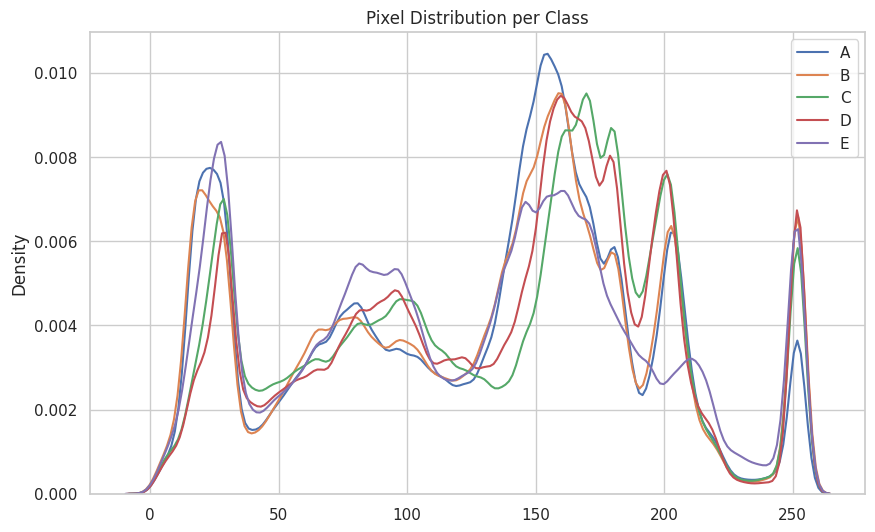

In [19]:
plt.figure(figsize=(10,6))

for cls in classes[:5]:  # visualize few classes
    cls_pixels = []
    
    for path in df[df['label'] == cls]['path'].sample(100):
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            cls_pixels.extend(img.flatten())
    
    sns.kdeplot(cls_pixels, label=cls)

plt.legend()
plt.title("Pixel Distribution per Class")
plt.show()